# 00 — Differential Context in Noisy Sensing

This notebook introduces the core idea behind **differential-context-sensing**:

> Two noisy sensors can look bad individually, while their difference preserves the signal if the dominant noise is shared.

The toy model is motivated by arXiv:2504.09158, where a differential atom-interferometer readout cancels common-mode laser phase noise and preserves Standard Quantum Limit behavior.

## Setup

This notebook is intentionally self-contained. It does **not** import the local `src/` package, so it should run in Colab even if the repo package has not been installed.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust path handling for both local notebooks and Colab clones.
# In the repo, this notebook lives in notebooks/, so repo root is one level up.
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

if NOTEBOOK_DIR.name == "notebooks":
    ROOT = NOTEBOOK_DIR.parent
else:
    # Colab often starts in the repo root after %cd differential-context-sensing.
    ROOT = NOTEBOOK_DIR

DATA = ROOT / "data"
FIGURES = ROOT / "figures"
DATA.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

print(f"ROOT    = {ROOT}")
print(f"DATA    = {DATA}")
print(f"FIGURES = {FIGURES}")

ROOT    = /mnt/data/differential-context-sensing
DATA    = /mnt/data/differential-context-sensing/data
FIGURES = /mnt/data/differential-context-sensing/figures


## Sensing model

Sensor A and Sensor B each measure a physical phase.

Both sensors receive:

- a true differential signal,
- shared common-mode noise,
- independent local noise.

The observed phases are:

\[
\phi_A = +\frac{s}{2} + n_{\mathrm{common}} + n_A
\]

\[
\phi_B = -\frac{s}{2} + n_{\mathrm{common}} + n_B
\]

The differential phase is:

\[
\phi_{\mathrm{diff}} = \phi_A - \phi_B = s + n_A - n_B
\]

The shared noise cancels.

In [2]:
rng = np.random.default_rng(42)

n = 1000
t = np.linspace(0, 10, n)

signal = 0.3 * np.sin(2 * np.pi * 0.4 * t)
common_noise = 2.0 * rng.normal(size=n)
local_a = 0.15 * rng.normal(size=n)
local_b = 0.15 * rng.normal(size=n)

phi_a = 0.5 * signal + common_noise + local_a
phi_b = -0.5 * signal + common_noise + local_b
phi_diff = phi_a - phi_b

print("Simulated two sensors with strong shared noise and weak local noise.")

Simulated two sensors with strong shared noise and weak local noise.


## Individual sensors

Each sensor is dominated by the injected common-mode noise. The underlying signal is visually hard to recover from either sensor alone.

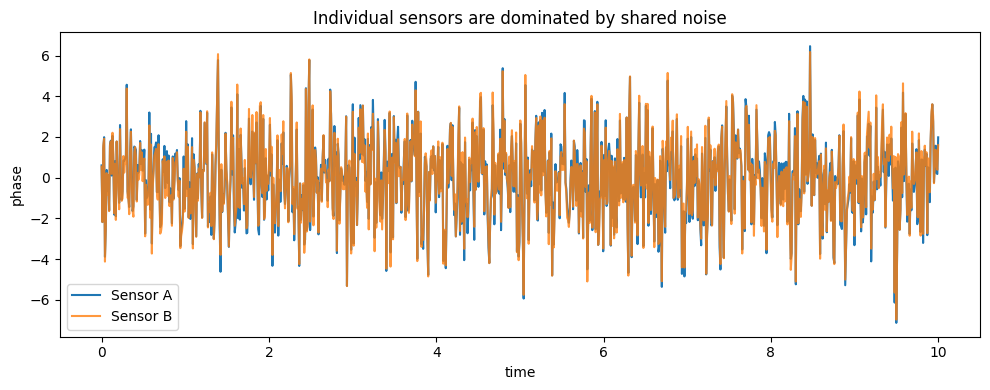

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(t, phi_a, label="Sensor A")
plt.plot(t, phi_b, label="Sensor B", alpha=0.8)
plt.xlabel("time")
plt.ylabel("phase")
plt.title("Individual sensors are dominated by shared noise")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "00_individual_sensors.png", dpi=200)
plt.show()

## Differential recovery

When the two sensor outputs are subtracted, the common-mode term cancels. The differential trace recovers the true signal up to local sensor noise.

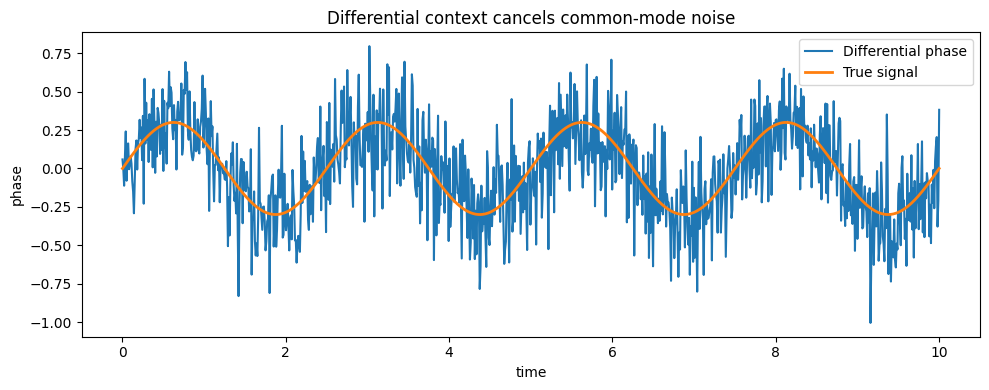

In [4]:
plt.figure(figsize=(10, 4))
plt.plot(t, phi_diff, label="Differential phase")
plt.plot(t, signal, label="True signal", linewidth=2)
plt.xlabel("time")
plt.ylabel("phase")
plt.title("Differential context cancels common-mode noise")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES / "00_differential_recovery.png", dpi=200)
plt.show()

## Quantify the improvement

We compare the error of an individual sensor against the differential readout.

In [5]:
individual_rmse = np.sqrt(np.mean((phi_a - 0.5 * signal) ** 2))
differential_rmse = np.sqrt(np.mean((phi_diff - signal) ** 2))
improvement_factor = individual_rmse / differential_rmse

summary = pd.DataFrame({
    "quantity": ["individual_sensor_error", "differential_error", "improvement_factor"],
    "value": [individual_rmse, differential_rmse, improvement_factor],
    "interpretation": [
        "dominated by common-mode noise",
        "common-mode noise cancels",
        "individual RMSE divided by differential RMSE",
    ],
})

summary.to_csv(DATA / "00_context_summary.csv", index=False)
summary

,quantity,value,interpretation
0,individual_sensor_error,1.983324,dominated by common-mode noise
1,differential_error,0.218780,common-mode noise cancels
2,improvement_factor,9.065399,individual RMSE divided by differential RMSE


## README figure

This bar chart gives the repo a simple first visual: apparent error drops once the shared context is subtracted.

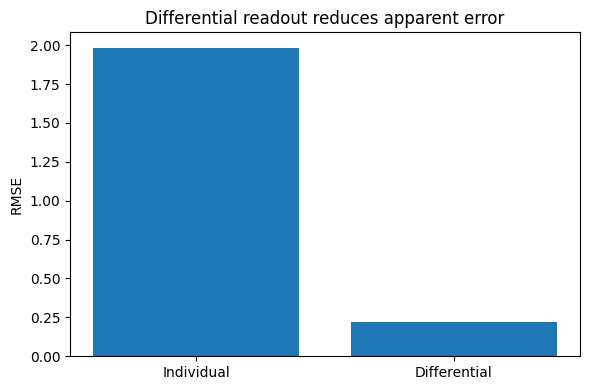

In [6]:
labels = ["Individual", "Differential"]
values = [individual_rmse, differential_rmse]

plt.figure(figsize=(6, 4))
plt.bar(labels, values)
plt.ylabel("RMSE")
plt.title("Differential readout reduces apparent error")
plt.tight_layout()
plt.savefig(FIGURES / "00_context_summary.png", dpi=200)
plt.show()

## Lesson

Shared noise is not automatically lost information.

If the measurement geometry identifies what is common and what is different, the common part can be rejected.

Notebook 07 will extend this model by separating signal amplitude, common-mode noise amplitude, and local sensor noise.